# **Setting Up the Environment and Data:**

### **Install Python Packages:**

In [1]:

!pip install transformers==4.44.2 numpy==1.26.4 --break-system-packages
!pip install pymilvus[milvus_lite]
!pip install --upgrade setuptools --break-system-packages

!pip install --force-reinstall -q \
    "sentence-transformers>=3.0" \
    "faiss-cpu" \
    "pymilvus" \
    "datasets" \
    "PyMuPDF" \
    "nltk"
!pip install "pymilvus[model]"
!pip install chromadb


  Using cached transformers-4.44.2-py3-none-any.whl.metadata (43 kB)
  Using cached numpy-1.26.4-cp311-cp311-macosx_11_0_arm64.whl.metadata (114 kB)
  Using cached huggingface_hub-0.36.2-py3-none-any.whl.metadata (15 kB)
  Using cached tokenizers-0.19.1-cp311-cp311-macosx_11_0_arm64.whl.metadata (6.7 kB)
Using cached transformers-4.44.2-py3-none-any.whl (9.5 MB)
Using cached numpy-1.26.4-cp311-cp311-macosx_11_0_arm64.whl (14.0 MB)
Using cached huggingface_hub-0.36.2-py3-none-any.whl (566 kB)
Using cached tokenizers-0.19.1-cp311-cp311-macosx_11_0_arm64.whl (2.4 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.3
    Uninstalling numpy-2.4.3:
      Successfully uninstalled numpy-2.4.3
  Attempting uninstall: huggingface-hub━━━━━━━━━ 0/4 [numpy]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0/4 [numpy]    WARNING: Ignoring invalid distribution ~ransformers (/Users/jerrychen/Desktop/School/CMU/WINTER26/GENAI/assignment2/myenv/lib/python3.11/site-packages)
    Found

### **Import Python Dependencies:**

In [2]:
import os
import sys
import json
import datetime
import huggingface_hub
import fitz
import nltk
import pymilvus
import transformers
import pandas as pd
import numpy as np

from sentence_transformers import SentenceTransformer
import chromadb

from typing import Literal, Protocol, TypeVar, Optional, Any, Callable
from io import StringIO
from dotenv import load_dotenv

from pymilvus import (
    utility,
    MilvusClient,
    FieldSchema,
    CollectionSchema,
    DataType,
    Collection,
    AnnSearchRequest,
    RRFRanker,
    connections,
)


from nltk.tokenize import sent_tokenize
nltk.download('punkt_tab')
nltk.download('punkt')



/Users/jerrychen/Desktop/School/CMU/WINTER26/GENAI/assignment2/myenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/jerrychen/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /Users/jerrychen/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

## **Define and retrieve environmental variables / secrets:**

In [3]:
MODEL_PATH = os.environ.get("QWEN_MODEL_PATH", "Qwen3.5-9B-MLX-4bit")

## **Custom Functions**

### *Chunker Functions*

In [4]:
def word_chunker(text, chunk_size=50, overlap=10):
        words = text.split()
        chunks = []
        i = 0
        while i < len(words):
            chunk = words[i:i + chunk_size]
            chunks.append(" ".join(chunk))
            i += chunk_size - overlap
        return chunks

In [5]:
# Create a chunker function to use a different chunking method
def sentence_chunker(text, chunk_size=50, overlap=10):
    sentences = sent_tokenize(text)
    chunks = []
    i = 0
    while i < len(sentences):
        chunk = sentences[i:i + chunk_size]
        chunks.append(" ".join(chunk))
        i += chunk_size - overlap
    return chunks


In [6]:
# Create a chunker function to use a different chunking method

### *Embedding Model Function*

In [7]:
def embedding_model(modelSelection: Literal["sentence_transformers"]):
    embedder = None  # always initialize first
    try:
        #if modelSelection == "default":
            #embedder = model.DefaultEmbeddingFunction() # This will download "all-MiniLM-L6-v2", a light weight model.

        if modelSelection == "sentence_transformers":
            embedder = model.dense.SentenceTransformerEmbeddingFunction(
                model_name='all-MiniLM-L6-v2', # Specify the model name
                device='cpu' # Specify the device to use, e.g., 'cpu' or 'cuda:0'
                )
    except Exception as e:
        print(f"An error occurred: {e}")
        raise
    return embedder

In [8]:
def encode_text(chunks: list[str], embedder: Callable):
  encodings = embedder(chunks)
  return encodings

In [9]:
def save_embeddings(embeddings, path="embeddings.json"):
    serializable = {
        "dense": [v.tolist() if isinstance(v, np.ndarray) else v
                  for v in embeddings["dense"]],
        "sparse": [
            {"indices": v.indices.tolist(), "values": v.data.tolist()}
            for v in embeddings["sparse"]
        ]
    }
    with open(path, "w") as f:
        json.dump(serializable, f)
    print(f"Saved to {path}")

In [10]:
def load_embeddings(path="embeddings.json"):
    with open(path, "r") as f:
        data = json.load(f)
    return {
        "dense": np.array(data["dense"]),
        "sparse": [
            {"indices": np.array(item["indices"]), "values": np.array(item["values"])}
            for item in data["sparse"]
        ]
    }


### *Vector Store Design and Usage Functions*

---



In [11]:
import chromadb
import numpy as np

def create_client(vectorStoreName: str, metric: str, vector_dimension: int = None):
    """
    Creates a persistent ChromaDB client and collection.
    vector_dimension is optional — ChromaDB infers it automatically.
    """
    client = chromadb.PersistentClient(path="./chroma_db")

    collection = client.get_or_create_collection(
        name=vectorStoreName,
        metadata={"hnsw:space": f"{metric}"}  # options: "cosine", "l2", "ip"
    )

    print(f"Collection '{vectorStoreName}' ready. Count: {collection.count()}")
    return client, collection


def insert_embeddings(collection, docs: list, embeddings: dict, ids: list = None):
    """
    Insert documents and their embeddings into ChromaDB.
    embeddings: dict with 'dense' key (from BGEM3EmbeddingFunction)
    """
    if ids is None:
        ids = [str(i) for i in range(len(docs))]

    dense_vectors = embeddings["dense"]
    if isinstance(dense_vectors, np.ndarray):
        dense_vectors = dense_vectors.tolist()

    collection.add(
        ids=ids,
        documents=docs,
        embeddings=dense_vectors
    )
    print(f"Inserted {len(docs)} documents.")


def query_collection(collection, query_embeddings: dict, n_results: int = 5):
    """
    Query the collection with a dense embedding vector.
    """
    dense_vector = query_embeddings["dense"]
    if isinstance(dense_vector, np.ndarray):
        dense_vector = dense_vector.tolist()

    results = collection.query(
        query_embeddings=dense_vector,
        n_results=n_results
    )
    return results

### *Chroma: list or delete collections*

Persistent data lives under `./chroma_db`. Typical names in this homework:

| Collection | Purpose |
|------------|---------|
| `hw02` | Section A — word-chunked handbook (rebuild only if you re-run the Section A embedding pipeline) |
| `hw02_alt_chunks` | Experiment B.II — sentence-window chunks (safe to delete before rebuilding after chunking changes) |

Use the next cell to **list** collections or **delete** by name (e.g. drop `hw02_alt_chunks` without touching `hw02`).


In [12]:
import chromadb  # redundant if the vector-store cell above already ran

def chroma_list_collections(path="./chroma_db"):
    """Print each collection name and document count."""
    client = chromadb.PersistentClient(path=path)
    for c in client.list_collections():
        print(f"{c.name!r}\tcount={c.count()}")


def chroma_delete_collection(name: str, path="./chroma_db"):
    """Remove one collection (embeddings + documents) by name."""
    client = chromadb.PersistentClient(path=path)
    client.delete_collection(name)
    print(f"Deleted collection {name!r}")

# Example usage (uncomment to run):
# chroma_list_collections()
# chroma_delete_collection("hw02_alt_chunks")  # B.II only; keeps Section A hw02 store intact


In [13]:
import chromadb
import numpy as np
import json
from collections import Counter
import matplotlib.pyplot as plt

def match_questions_to_documents(
    questions: list,
    question_embeddings: dict,
    collection,
    docs: list,
    n_results: int = 1,
    top_n: int = 30,
    save_path: str = "question_matches.json"
):
    dense_vectors = question_embeddings["dense"]
    if isinstance(dense_vectors, np.ndarray):
        dense_vectors = dense_vectors.tolist()

    print(f"Querying {len(questions)} questions against {collection.count()} documents...")

    results = collection.query(
        query_embeddings=dense_vectors,
        n_results=n_results,
        include=["documents", "distances", "metadatas"]
    )

    # 2. Attach most similar document to each question
    matched = []
    for i, question in enumerate(questions):
        matched.append({
            "question_id": i,
            "question": question,
            "matched_document": results["documents"][i][0],
            "matched_doc_id": results["ids"][i][0],
            "similarity_score": round(1 - results["distances"][i][0], 4)
        })

    # 3. Save results
    with open(save_path, "w") as f:
        json.dump(matched, f, indent=2)
    print(f"Saved {len(matched)} matches to {save_path}")

    # 4. Plot distribution
    doc_counts = Counter(m["matched_doc_id"] for m in matched)

    sorted_pairs = sorted(zip(doc_counts.values(), doc_counts.keys()), reverse=True)
    top_pairs = sorted_pairs[:top_n]
    counts_top, doc_ids_top = zip(*top_pairs)

    fig, axes = plt.subplots(1, 2, figsize=(20, 6))

    # Horizontal bar chart
    axes[0].barh(range(len(doc_ids_top)), counts_top, color="steelblue", edgecolor="white")
    axes[0].set_yticks(range(len(doc_ids_top)))
    axes[0].set_yticklabels(doc_ids_top, fontsize=8)
    axes[0].invert_yaxis()
    axes[0].set_xlabel("Number of Questions Matched")
    axes[0].set_ylabel("Document ID")
    axes[0].set_title(f"Top {top_n} Documents by Match Count")

    # Similarity score histogram
    scores = [m["similarity_score"] for m in matched]
    axes[1].hist(scores, bins=30, color="darkorange", edgecolor="white")
    axes[1].set_xlabel("Similarity Score")
    axes[1].set_ylabel("Number of Questions")
    axes[1].set_title("Distribution of Similarity Scores")

    plt.tight_layout()
    plt.savefig("question_doc_distribution.png", dpi=150)
    plt.show()
    print("Saved plot to question_doc_distribution.png")

    # Summary stats
    print(f"\n── Summary ──────────────────────────────")
    print(f"Total questions:       {len(questions)}")
    print(f"Unique docs matched:   {len(doc_counts)}")
    print(f"Most matched doc:      {doc_counts.most_common(1)[0]}")
    print(f"Avg similarity score:  {np.mean(scores):.4f}")
    print(f"Min similarity score:  {np.min(scores):.4f}")
    print(f"Max similarity score:  {np.max(scores):.4f}")

    return matched

## *Pydantic Models for LLM Judge Demo*

In [14]:
from pydantic import BaseModel, Field, field_validator
from typing import List
from enum import IntEnum

from pydantic import BaseModel, Field, field_validator, model_validator
from typing import List, Optional
from enum import IntEnum
import re
import json
# Local judge uses local model backends (mlx_lm or transformers).

class LikertScore(IntEnum):
    STRONGLY_DISAGREE = 1
    DISAGREE = 2
    NEUTRAL = 3
    AGREE = 4
    STRONGLY_AGREE = 5

# ── Pricing per 1M tokens (input, output) in USD ──────────────────────────────
MODEL_PRICING = {
    # Mistral
    "mistralai/Mistral-7B-Instruct-v0.3":       (0.10,  0.10),
    "mistralai/Mixtral-8x7B-Instruct-v0.1":     (0.50,  0.50),
    "mistralai/Mistral-Nemo-Instruct-2407":      (0.10,  0.10),
    # Meta Llama
    "meta-llama/Llama-3.1-8B-Instruct":         (0.10,  0.10),
    "meta-llama/Llama-3.1-70B-Instruct":        (0.40,  0.40),
    "meta-llama/Llama-3.3-70B-Instruct":        (0.40,  0.40),
    # Qwen
    "Qwen/Qwen2.5-7B-Instruct":                 (0.10,  0.10),
    "Qwen/Qwen2.5-72B-Instruct":                (0.40,  0.40),
    "Qwen/Qwen2.5-Coder-32B-Instruct":          (0.20,  0.20),
    # Google
    "google/gemma-2-9b-it":                     (0.10,  0.10),
    "google/gemma-2-27b-it":                    (0.27,  0.27),
}

def get_token_cost(model_id: str, input_tokens: int, output_tokens: int) -> dict:
    """Calculate cost based on model pricing."""
    if model_id not in MODEL_PRICING:
        return {
            "model_id": model_id,
            "input_tokens": input_tokens,
            "output_tokens": output_tokens,
            "total_tokens": input_tokens + output_tokens,
            "cost_usd": None,
            "cost_per_1m_in": None,
            "cost_per_1m_out": None,
        }

    price_in, price_out = MODEL_PRICING[model_id]
    cost = (input_tokens * price_in / 1_000_000) + (output_tokens * price_out / 1_000_000)

    return {
        "model_id":       model_id,
        "input_tokens":   input_tokens,
        "output_tokens":  output_tokens,
        "total_tokens":   input_tokens + output_tokens,
        "cost_usd":       round(cost, 8),
        "cost_per_1m_in": price_in,
        "cost_per_1m_out": price_out,
    }

# ── Pydantic Models ────────────────────────────────────────────────────────────

class TokenUsage(BaseModel):
    model_id:        str
    input_tokens:    int
    output_tokens:   int
    total_tokens:    int
    cost_usd:        Optional[float] = None
    cost_per_1m_in:  Optional[float] = None
    cost_per_1m_out: Optional[float] = None

class DocumentRelevance(BaseModel):
    doc_id:               str
    document_snippet:     str
    relevance_score:      LikertScore
    relevance_rationale:  str

class QuestionRelevanceEval(BaseModel):
    question_id:       int
    question:          str
    construct:         str = Field(default="relevance")
    document_evals:    List[DocumentRelevance]
    overall_score:     LikertScore
    overall_rationale: str
    token_usage:       Optional[TokenUsage] = None

    @field_validator("document_evals")
    @classmethod
    def must_have_at_least_one(cls, v):
        if len(v) == 0:
            raise ValueError("Must have at least one document evaluation")
        return v

    @property
    def mean_score(self) -> float:
        return sum(d.relevance_score for d in self.document_evals) / len(self.document_evals)

    @property
    def score_distribution(self) -> dict:
        return {score.name: sum(1 for d in self.document_evals if d.relevance_score == score)
                for score in LikertScore}


/var/folders/hw/yxwyz93n6bnfmq75trqppqqr0000gn/T/ipykernel_2555/383999716.py:81: UserWarning: Field name "construct" in "QuestionRelevanceEval" shadows an attribute in parent "BaseModel"
  class QuestionRelevanceEval(BaseModel):


## *Metric Functions for Evaluation (Section C)*

In [15]:
def evaluate_relevance_hf(
    question:     str,
    question_id:  int,
    matched_docs: list,
    hf_token:     str,
    model_id:     str = "Qwen/Qwen2.5-72B-Instruct",
    construct:    str = "relevance"
) -> QuestionRelevanceEval:

    client_hf = InferenceClient(token=hf_token)

    docs_text = "\n\n".join([
        f"[Doc {d['matched_doc_id']}]: {d['matched_document']}"
        for d in matched_docs
    ])

    doc_template = ", ".join([
        f'{{"doc_id": "{d["matched_doc_id"]}", "document_snippet": "...", '
        f'"relevance_score": 0, "relevance_rationale": "..."}}'
        for d in matched_docs
    ])

    prompt = f"""You are evaluating the {construct} of retrieved documents to a question.

Question: {question}

Retrieved Documents:
{docs_text}

Score each document's {construct} on a 5-point Likert scale:
1 = Strongly Disagree (not {construct} at all)
2 = Disagree (mostly not {construct})
3 = Neutral (neither somewhat {construct} nor somewhat not {construct})
4 = Agree (mostly {construct})
5 = Strongly Agree (highly {construct})

Respond with ONLY a valid JSON object, no markdown, no extra text:
{{
  "question_id": {question_id},
  "question": {json.dumps(question)},
  "construct": "{construct}",
  "document_evals": [{doc_template}],
  "overall_score": 0,
  "overall_rationale": "<summary>"
}}

"overall_score" must be a single integer from 1 to 5. Do not average — pick the most representative score."""

    response = client_hf.chat_completion(
        model=model_id,
        messages=[{"role": "user", "content": prompt}],
        max_tokens=1500,
        temperature=0.1,
    )

    raw = response.choices[0].message.content.strip()

    # Strip markdown fences if present
    raw = re.sub(r"```(?:json)?\s*", "", raw).strip()

    # Extract JSON robustly
    json_match = re.search(r'\{.*\}', raw, re.DOTALL)
    if not json_match:
        raise ValueError(f"No JSON found in response:\n{raw}")

    parsed = json.loads(json_match.group())

    # Coerce overall_score to valid integer (model may return a float average)
    if "overall_score" in parsed:
        parsed["overall_score"] = min(5, max(1, round(parsed["overall_score"])))

    # ── Compute cost from usage metadata ──────────────────────────────────
    usage = response.usage
    token_usage = TokenUsage(**get_token_cost(
        model_id=model_id,
        input_tokens=usage.prompt_tokens,
        output_tokens=usage.completion_tokens,
    ))

    return QuestionRelevanceEval(**parsed, token_usage=token_usage)

In [16]:
def evaluate_precision_recall(
    matched: list,
    eval_results: list[QuestionRelevanceEval],
    relevance_threshold: LikertScore = LikertScore.AGREE,  # score >= 4 = relevant
) -> dict:
    """
    Precision: of all documents retrieved, how many were actually relevant?
    Recall:    of all relevant documents, how many were retrieved?

    matched:        output of match_questions_to_documents()
    eval_results:   list of QuestionRelevanceEval from evaluate_relevance_hf()
    relevance_threshold: minimum LikertScore to count as relevant (default: 4)
    """

    total_retrieved = 0
    total_relevant_retrieved = 0
    total_relevant = 0

    per_question = []

    for eval_result in eval_results:
        n_retrieved = len(eval_result.document_evals)
        n_relevant_retrieved = sum(
            1 for d in eval_result.document_evals
            if d.relevance_score >= relevance_threshold
        )
        # Recall denominator: treat all docs in collection as potential relevant pool
        # Use overall_score as a proxy — if overall >= threshold, at least 1 relevant doc exists
        n_relevant = max(n_relevant_retrieved, 1) if eval_result.overall_score >= relevance_threshold else n_relevant_retrieved

        precision = n_relevant_retrieved / n_retrieved if n_retrieved > 0 else 0.0
        recall    = n_relevant_retrieved / n_relevant  if n_relevant  > 0 else 0.0
        f1        = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

        per_question.append({
            "question_id":          eval_result.question_id,
            "question":             eval_result.question,
            "n_retrieved":          n_retrieved,
            "n_relevant_retrieved": n_relevant_retrieved,
            "precision":            round(precision, 4),
            "recall":               round(recall, 4),
            "f1":                   round(f1, 4),
            "mean_relevance_score": round(eval_result.mean_score, 4),
        })

        total_retrieved          += n_retrieved
        total_relevant_retrieved += n_relevant_retrieved
        total_relevant           += n_relevant

    # Macro averages (average of per-question scores)
    macro_precision = sum(q["precision"] for q in per_question) / len(per_question)
    macro_recall    = sum(q["recall"]    for q in per_question) / len(per_question)
    macro_f1        = sum(q["f1"]        for q in per_question) / len(per_question)

    # Micro averages (aggregate counts first, then divide)
    micro_precision = total_relevant_retrieved / total_retrieved if total_retrieved > 0 else 0.0
    micro_recall    = total_relevant_retrieved / total_relevant  if total_relevant  > 0 else 0.0
    micro_f1        = (2 * micro_precision * micro_recall) / (micro_precision + micro_recall) if (micro_precision + micro_recall) > 0 else 0.0

    summary = {
        "threshold":       relevance_threshold.name,
        "n_questions":     len(eval_results),
        "macro_precision": round(macro_precision, 4),
        "macro_recall":    round(macro_recall, 4),
        "macro_f1":        round(macro_f1, 4),
        "micro_precision": round(micro_precision, 4),
        "micro_recall":    round(micro_recall, 4),
        "micro_f1":        round(micro_f1, 4),
        "per_question":    per_question,
    }

    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    metrics = ["precision", "recall", "f1"]
    colors  = ["steelblue", "darkorange", "seagreen"]

    for ax, metric, color in zip(axes, metrics, colors):
        scores = [q[metric] for q in per_question]
        ax.hist(scores, bins=20, color=color, edgecolor="white")
        ax.axvline(np.mean(scores), color="black", linestyle="--", linewidth=1.5, label=f"mean={np.mean(scores):.2f}")
        ax.set_title(f"Per-Question {metric.capitalize()}")
        ax.set_xlabel(metric.capitalize())
        ax.set_ylabel("Number of Questions")
        ax.legend()

    plt.suptitle(f"Precision / Recall / F1  (threshold: {relevance_threshold.name} = {relevance_threshold})", fontsize=13)
    plt.tight_layout()
    plt.savefig("precision_recall.png", dpi=150)
    plt.show()

    print(f"\n── Summary (threshold ≥ {relevance_threshold.name}) ─────────────────")
    print(f"Macro  Precision: {macro_precision:.4f}  Recall: {macro_recall:.4f}  F1: {macro_f1:.4f}")
    print(f"Micro  Precision: {micro_precision:.4f}  Recall: {micro_recall:.4f}  F1: {micro_f1:.4f}")

    return summary

### **Load CMU Policy Handbook PDF into the environment:**

In [17]:
doc = fitz.open("CMU Student Handbook 2023-24.pdf")

out = open("cmu_policy.txt", "wb") # create a text output

for page in doc: # iterate the document pages
    text = page.get_text().encode("utf8") # get plain text (is in UTF-8)
    out.write(text) # write text of page
    out.write(bytes((12,))) # write page delimiter (form feed 0x0C)
out.close()

# **Section A: Experimenting with Queries in a Standard Vectore Store**


## **Learning Objectives:**
> [1] Know how to build and evaluate the information retrieval of a basic RAG system (with no LLM integration):
>> * Understand how to tokenize a document: What does tokenization entail? How do we know what tokenizer model to use for this task?
>> * Understand how to select and use a data chunking strategy to break up a document and to create embeddings (knowledge represetations) to use for retrieving information from the vector store that is relevant to the user queries.
>> * Conduct query experiments and analyze the RAG information retrieval quality by assessing the information retrieved from the vector store in response to the queries.



## *Chunk the text of the CMU Policy Handbook*



In [18]:
text_chunks = [] # create an empty list to store the text chunks.
doc_idxs = []    # create an empty list to store unique identifiers for the text chunks.
chunked_policy_df = pd.DataFrame() # create an empty dataframe to store the text chunks.

In [19]:
'''
1. Select a chunking strategy.
2. Chunk the text of the CMU Policy Handbook.
3. Assign a unique identifier to each chunk that represents the original page in the handbook where the chunk is located.

'''

for doc_idx, page in enumerate(doc):
    page_text = page.get_text("text") # this grabs the text from each page of the CMU policy handbook PDF.
    cur_text_chunks = word_chunker(page_text, chunk_size=50, overlap=10) # Chunker Selection == word chunker. Change this in Section B of your homework.
    text_chunks.extend(cur_text_chunks)
    doc_idxs.extend([doc_idx] * len(cur_text_chunks))

In [20]:
# ADD UNIQUE IDENTIFIER (to each chunk)
chunked_policy_df['page_id'] = doc_idxs # put the page_id for each chunk into a pandas dataframe. Note that the page_id identifies the page location in the original PDF of the text.

In [21]:
# ADD EACH CHUNK TO THE DATAFRAME:
chunked_policy_df['text'] =text_chunks  # put the chunked text into the dataframe.

In [22]:
chunked_policy_df # glance at the Dataframe to check for errors.

,page_id,text
0,0,1 The Word: Student Handbook 2023-2024
1,1,2 Welcome to The Word 2023-2024 The Word stude...
2,1,all students will reach their highest potentia...
3,1,of our university. To ensure you are knowledge...
4,1,community. We hope you will take advantage of ...
...,...,...
2610,294,295 Case-specific questions regarding timefram...
2611,295,296 Appendix: Student Resources • Center for S...
2612,295,https://www.cmu.edu/current-students/index.htm...
2613,296,297 • The HUB: https://www.cmu.edu/hub/ • Offi...


In [23]:
len(chunked_policy_df['text'])

2615

## Select an Embedding Model

In [24]:
import transformers
from transformers import AlbertTokenizer
from pymilvus import model

# other options:
#model = SentenceTransformer('bert-base-nli-mean-tokens') # here we are selecting to use a Bert model on HuggingFace to create the embeddings.

embedder = embedding_model("sentence_transformers")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6409.03it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [25]:
# save the text chunks of the CMU Policy Handbook to a list
docs = chunked_policy_df['text'].tolist()

# create embeddings from the text chunks of the CMU Policy Handbook:
embeddings = embedder.encode_documents(docs) # this might take a long time, if it does, that is not atypical especially if you're working on CPU (versus GPU)

In [26]:
# save the CMU Policy Handbook Embeddings:

save_embeddings({"dense": embeddings, "sparse": []}, path="cmu_handbook_embeddings.json")

Saved to cmu_handbook_embeddings.json


In [27]:
'''
If needed, use the function below to load the embeddings back into your notebook.
'''
embeddings = load_embeddings("cmu_handbook_embeddings.json")

## *Design the Vector Store*

**Tasks:**
> Select a similarity, distance or clustering algorithm to use in the Vector Store.

> Upload the embeddings of the chunked CMU Policy Handbook to the Vector Store.

> Check that the vector store was properly created and working.

In [28]:
# Create the vector store
client, collection = create_client(vectorStoreName="hw02", metric="cosine")

Collection 'hw02' ready. Count: 2615


In [29]:
# Inspect the vector store
collection

Collection(name=hw02)

In [30]:
# upload the embeddings:
docs=chunked_policy_df['text']
insert_embeddings(collection, list(chunked_policy_df['text']), embeddings)

Inserted 2615 documents.


## *Design the Query Experiment*

**Tasks:**
> Create Python objects that define the questions (`queries') that you will use in the experiment. Note: please use the questions provided to you in the Homework Assignment instructions.

>> Encode these query objects and save them in the environment.

> Select evaluation metrics to assess the quality of the information retrieved from the vector store.

> Retrieve information from the vector store using the queries.

> Measure the quality of the information retrieval using the evaluation metrics that you chose.

In [31]:
# Define the queries for the experiments
q1="What is the academic integrity policy?"
q2="How is cheating defined in the policy?"
q3="What is the policy for improper or illegal communications?"
q4="What are CMU’s quiet hours?"
q5= "Where are pets or animals allowed on CMU’s campus?"

In [32]:
# define the list of questions that you will submit to the vector store:
questions=pd.Series([q1, q2, q3, q4, q5])

#
q01 = pd.Series([q1])
q02 = pd.Series([q2])
q03 = pd.Series([q3])
q04 = pd.Series([q4])
q05 = pd.Series([q5])

In [33]:
# Encode the queries for the experiments using the embedding model
question_embedding = embedder.encode_documents(q01.tolist())

In [34]:
question_embedding

[array([-3.73943225e-02,  9.98494998e-02, -3.68607417e-02, -3.51854265e-02,
         2.37348061e-02, -1.70656275e-02, -3.40798721e-02, -8.68340358e-02,
        -1.54793228e-03,  6.92967027e-02,  5.04572093e-02,  8.24571624e-02,
        -3.37054208e-02, -2.73006968e-02, -9.46990624e-02,  1.80964712e-02,
        -5.24988510e-02,  1.17457379e-02, -4.06726040e-02, -2.24045962e-02,
         5.08646062e-03,  2.71296259e-02,  4.15171981e-02,  4.43458706e-02,
        -3.75666879e-02, -4.56076302e-03, -3.13719781e-03, -5.42213283e-02,
        -5.58070950e-02, -8.69289935e-02, -5.29440790e-02, -2.69563571e-02,
         1.82095859e-02,  3.29573527e-02, -2.11109314e-02,  9.53177139e-02,
         2.09778566e-02, -3.37007409e-03,  2.45418977e-02,  2.53806403e-03,
        -2.58776639e-02, -2.88361683e-02, -3.16623226e-02,  3.73185277e-02,
        -1.05607314e-02, -7.15818703e-02,  4.87464555e-02, -6.59105629e-02,
         9.01939720e-03, -1.15874009e-02, -6.04182780e-02, -3.66622619e-02,
         2.4

In [35]:
# save the question embeddings:
#save_embeddings(question_embedding, path="q01_embeddings.json")
save_embeddings({"dense": question_embedding, "sparse": []}, path="q01_embeddings.json")

Saved to q01_embeddings.json


In [36]:
q01_embeddings = load_embeddings("q01_embeddings.json")

In [37]:
# Search the vector store and retrieve information using the queries
vs_search_results = query_collection(collection, q01_embeddings, n_results= 5)
vs_search_results

{'ids': [['1046', '1032', '2360', '106', '68']],
 'embeddings': None,
 'documents': [['involving alleged violations of the University Policy on Academic Integrity, the following procedures apply:',
   'of the University Policy on Academic Integrity including cheating, plagiarism, and unauthorized assistance. • Academic Integrity Liaison: Each department designates an individual who is trained by the Office of Community Standards and Integrity to provide guidance to course instructors in cases of alleged violations of the University Policy on Academic',
   'academic integrity of our community. The Word provides a list of policies students are expected to uphold and the process by which violations will be addressed. Policies and procedures may be established or amended as necessary during the course of the academic year, which will become effective immediately upon notification',
   'when any student violates the University Policy on Academic Integrity including cheating, plagiarism and 

In [38]:
# repeat for each question
for idx, question in enumerate(questions, 1):
    question_embedding = embedder.encode_documents([question])
    save_embeddings({"dense": question_embedding, "sparse": []}, path=f"q{idx:02d}_embeddings.json")
    q_embeddings = load_embeddings(f"q{idx:02d}_embeddings.json")
    vs_search_results = query_collection(collection, q_embeddings, n_results=5)
    print(f"\nTop 5 documents for Question {idx}: {question}")
    for doc in vs_search_results['documents'][0]:
        print(doc + "\n")
    
    

Saved to q01_embeddings.json

Top 5 documents for Question 1: What is the academic integrity policy?
involving alleged violations of the University Policy on Academic Integrity, the following procedures apply:

of the University Policy on Academic Integrity including cheating, plagiarism, and unauthorized assistance. • Academic Integrity Liaison: Each department designates an individual who is trained by the Office of Community Standards and Integrity to provide guidance to course instructors in cases of alleged violations of the University Policy on Academic

academic integrity of our community. The Word provides a list of policies students are expected to uphold and the process by which violations will be addressed. Policies and procedures may be established or amended as necessary during the course of the academic year, which will become effective immediately upon notification

when any student violates the University Policy on Academic Integrity including cheating, plagiarism and u

# **Section B: Experimenting with an Retrieved_Number ('Top K') Parameter and Alternative Chunking and Embedding Strategies.**

## **Learning Objectives:**
> [1] [insert]


## **General Instructions:**
> [1] Choose one of the five (5) questions from Section A to use in three (3) different experiments that you will run in this section, Section B.

> [2] **Experiment 1:** Run the query you selected in a search of the vector store, varying the 'retrieved_number' or 'top_k' parameter according to the homework assignment instructions. Make sure to record the input and output from the vector store. You'll need this record to complete Part C.

> [3] **Experiment 2:** Follow the steps in Section A for building a vector store BUT this time, choose a different **chunking** strategy, re-create the document embeddings for these new chunks, and upload to the new vector store. Then, submit your chosen query to the story, varying the 'retrieved_number' or 'top_k' parameter according to the homework assignment instructions, as you did in step_2, above. Make sure to record the input and output from the vector store. You'll need this record to complete Part C.

> [4] **Experiment 3:** Follow the steps in Section A for building a vector store, while using the SAME chunking strategy that you used in Experiment 2, for this experiment 3, use the **embedding** strategy detailed below; with these embeddings (described below), upload them to the new vector store. Then, submit your chosen query to the story, varying the 'retrieved_number' or 'top_k' parameter according to the homework assignment instructions, as you did in step_2 and step_3, above. Make sure to record the input and output from the vector store. You'll need this record to complete Part C.

>> Instead of using the CMU Policy Document chunks for your embeddings, instead, convert the list of questions provided to you (and posted to Canvas), convert those questions to embeddings and attached the CMU Policy Document chunks to questions that are relevant to the Policy Document Chunk. Upload the `policy question embeddings` and the attached metadata (e.g. the CMU Policy Document Chunks) to the vector store. Then, repeat the experiment but using this vector store design. Record the input and output from the vector store.



> **Reminder**: Record the input (query) and output (vector store responses) of each experiment. You'll need this record to complete Section C.

## *Design the Query Experiment*

**Tasks:**
> [1] Create Python objects that define the questions (`queries') that you will use in the experiment. Note: please use the questions provided to you in the Homework Assignment instructions.

>> [1.a]Encode these query objects and save them in the environment.

> [2] Retrieve information from the vector store using the queries.

> [3] Save the retrieved information in the Google spreadsheet (a template is provided in the Homework Assignment Document posted to Canvas)

## *Experiment B.I: Varying the Retrieved_Number ('Top_K') Parameter.*


In [39]:
# Define the query chosen for the experiment.
qb = "What is the academic integrity policy?"

In [40]:
# Encode the query for the experiment using the embedding model.
question_embedding_qb = embedder.encode_documents([qb])
question_embedding_qb


[array([-3.73943225e-02,  9.98494998e-02, -3.68607417e-02, -3.51854265e-02,
         2.37348061e-02, -1.70656275e-02, -3.40798721e-02, -8.68340358e-02,
        -1.54793228e-03,  6.92967027e-02,  5.04572093e-02,  8.24571624e-02,
        -3.37054208e-02, -2.73006968e-02, -9.46990624e-02,  1.80964712e-02,
        -5.24988510e-02,  1.17457379e-02, -4.06726040e-02, -2.24045962e-02,
         5.08646062e-03,  2.71296259e-02,  4.15171981e-02,  4.43458706e-02,
        -3.75666879e-02, -4.56076302e-03, -3.13719781e-03, -5.42213283e-02,
        -5.58070950e-02, -8.69289935e-02, -5.29440790e-02, -2.69563571e-02,
         1.82095859e-02,  3.29573527e-02, -2.11109314e-02,  9.53177139e-02,
         2.09778566e-02, -3.37007409e-03,  2.45418977e-02,  2.53806403e-03,
        -2.58776639e-02, -2.88361683e-02, -3.16623226e-02,  3.73185277e-02,
        -1.05607314e-02, -7.15818703e-02,  4.87464555e-02, -6.59105629e-02,
         9.01939720e-03, -1.15874009e-02, -6.04182780e-02, -3.66622619e-02,
         2.4

In [41]:
# Search the vector store [varying the retrieved_numer (top_k) Parameter] and retrieve information using the queries
top_ks = [1, 3, 5, 10]
vs_search_results = {}
for k in top_ks:
    vs_search_results[k] = query_collection(collection, {"dense": question_embedding_qb}, n_results=k)
    print(f"Top {k} documents for Question {qb}:")
    for doc in vs_search_results[k]['documents'][0]:
        print(doc + "\n")


Top 1 documents for Question What is the academic integrity policy?:
involving alleged violations of the University Policy on Academic Integrity, the following procedures apply:

Top 3 documents for Question What is the academic integrity policy?:
involving alleged violations of the University Policy on Academic Integrity, the following procedures apply:

of the University Policy on Academic Integrity including cheating, plagiarism, and unauthorized assistance. • Academic Integrity Liaison: Each department designates an individual who is trained by the Office of Community Standards and Integrity to provide guidance to course instructors in cases of alleged violations of the University Policy on Academic

academic integrity of our community. The Word provides a list of policies students are expected to uphold and the process by which violations will be addressed. Policies and procedures may be established or amended as necessary during the course of the academic year, which will become 

In [42]:
# Save the input and output from the vector store.

## *Experiment B.II: Using an Alternative Chunking Strategy.*

Same workflow as **Experiment B.I** (define query → encode → vary `top_k`), but the vector store is rebuilt with a **different chunking strategy** than Section A (sentence windows instead of word windows). Use the **same query string as B.I** so Section B experiments are comparable.


In [43]:
# Choose a DIFFERENT chunking strategy AND remake the vector store using these new chunks.
# Section A used word_chunker(..., chunk_size=50, overlap=10).
# Here we switch to sentence-based chunking for Experiment B.II.

alt_chunk_size = 5
alt_overlap = 1

text_chunks_alt = []
doc_idxs_alt = []
chunked_policy_df_alt = pd.DataFrame()

# Use a fresh PDF handle here to avoid collisions if `doc` was reused elsewhere.
with fitz.open("CMU Student Handbook 2023-24.pdf") as handbook_doc:
    for doc_idx, page in enumerate(handbook_doc):
        page_text = page.get_text("text")
        cur_text_chunks = sentence_chunker(page_text, chunk_size=alt_chunk_size, overlap=alt_overlap)
        text_chunks_alt.extend(cur_text_chunks)
        doc_idxs_alt.extend([doc_idx] * len(cur_text_chunks))

chunked_policy_df_alt["page_id"] = doc_idxs_alt
chunked_policy_df_alt["text"] = text_chunks_alt

# Embed alternative chunks.
docs_alt = chunked_policy_df_alt["text"].tolist()
embeddings_alt = embedder.encode_documents(docs_alt)

# Build / reuse dedicated B.II collection.
client_alt, collection_alt = create_client(vectorStoreName="hw02_alt_chunks", metric="cosine")

# If the collection already has data from a previous run, clear it so this run is reproducible.
existing_count = collection_alt.count()
if existing_count > 0:
    existing_ids = collection_alt.get(include=[]).get("ids", [])
    if existing_ids:
        collection_alt.delete(ids=existing_ids)

insert_embeddings(collection_alt, docs_alt, {"dense": embeddings_alt, "sparse": []})
print(f"Alternative chunk collection count: {collection_alt.count()}")
print(f"Number of sentence-window chunks: {len(docs_alt)}")


Collection 'hw02_alt_chunks' ready. Count: 1130
Inserted 1130 documents.
Alternative chunk collection count: 1130
Number of sentence-window chunks: 1130


In [44]:
# check if the vector store was properly created and working.
collection_alt

Collection(name=hw02_alt_chunks)

In [45]:
# Define the query chosen for the experiment (same as Experiment B.I — homework: one question for all Section B experiments).
qb = "What is the academic integrity policy?"

In [46]:
# Encode the query for the experiment using the embedding model.
question_embedding_qb_b2 = embedder.encode_documents([qb])
question_embedding_qb_b2


[array([-3.73943225e-02,  9.98494998e-02, -3.68607417e-02, -3.51854265e-02,
         2.37348061e-02, -1.70656275e-02, -3.40798721e-02, -8.68340358e-02,
        -1.54793228e-03,  6.92967027e-02,  5.04572093e-02,  8.24571624e-02,
        -3.37054208e-02, -2.73006968e-02, -9.46990624e-02,  1.80964712e-02,
        -5.24988510e-02,  1.17457379e-02, -4.06726040e-02, -2.24045962e-02,
         5.08646062e-03,  2.71296259e-02,  4.15171981e-02,  4.43458706e-02,
        -3.75666879e-02, -4.56076302e-03, -3.13719781e-03, -5.42213283e-02,
        -5.58070950e-02, -8.69289935e-02, -5.29440790e-02, -2.69563571e-02,
         1.82095859e-02,  3.29573527e-02, -2.11109314e-02,  9.53177139e-02,
         2.09778566e-02, -3.37007409e-03,  2.45418977e-02,  2.53806403e-03,
        -2.58776639e-02, -2.88361683e-02, -3.16623226e-02,  3.73185277e-02,
        -1.05607314e-02, -7.15818703e-02,  4.87464555e-02, -6.59105629e-02,
         9.01939720e-03, -1.15874009e-02, -6.04182780e-02, -3.66622619e-02,
         2.4

In [47]:
# Search the vector store [varying the retrieved_number (top_k) parameter] and retrieve information using the queries
top_ks = [1, 3, 5, 10]
vs_search_results_alt = {}
for k in top_ks:
    vs_search_results_alt[k] = query_collection(collection_alt, {"dense": question_embedding_qb_b2}, n_results=k)
    print(f"Top {k} documents for Question {qb}:")
    for doc in vs_search_results_alt[k]['documents'][0]:
        print(doc + "\n next doc starts here: ")


Top 1 documents for Question What is the academic integrity policy?:
In all cases involving alleged violations of the University Policy on 
Academic Integrity, the following procedures apply:
 next doc starts here: 
Top 3 documents for Question What is the academic integrity policy?:
In all cases involving alleged violations of the University Policy on 
Academic Integrity, the following procedures apply:
 next doc starts here: 
You should also become familiar with the following sources, 
which are the primary documents governing academic policies: the University Policies website, 
the Undergraduate Catalog, and individual department handbooks provided to each graduate 
student. Academic Disciplinary Actions Overview 
Academic disciplinary actions are outcomes imposed when any student violates the 
University Policy on Academic Integrity including cheating, plagiarism and unauthorized 
assistance. Academic Integrity Policy  
Students at Carnegie Mellon are engaged in intellectual activi

In [48]:
# Save the input and output from the vector store.

## *Experiment B.III: Using an Alternative Embedding Strategy.*



In [49]:
policy_questions = pd.read_csv('CMU_Handbook_1000_Questions.csv')
policy_questions

,Question Number,Section,Question,Document Embeddings
0,1,"SECTION 1: VISION, MISSION & CMU CODE (Q1–Q25)",What is Carnegie Mellon University's stated vi...,NaN
1,2,"SECTION 1: VISION, MISSION & CMU CODE (Q1–Q25)",What are the three primary goals outlined in C...,NaN
2,3,"SECTION 1: VISION, MISSION & CMU CODE (Q1–Q25)","According to CMU's mission, what four areas of...",NaN
3,4,"SECTION 1: VISION, MISSION & CMU CODE (Q1–Q25)",What does the Carnegie Mellon Code state about...,NaN
4,5,"SECTION 1: VISION, MISSION & CMU CODE (Q1–Q25)","According to the CMU Code, what must students ...",NaN
...,...,...,...,...
995,996,SECTION 20: STUDENT RESOURCES & MISCELLANEOUS ...,What is the policy on late submission of an in...,NaN
996,997,SECTION 20: STUDENT RESOURCES & MISCELLANEOUS ...,What happens to a student's full-time status i...,NaN
997,998,SECTION 20: STUDENT RESOURCES & MISCELLANEOUS ...,What is the role of the associate dean in gran...,NaN
998,999,SECTION 20: STUDENT RESOURCES & MISCELLANEOUS ...,What is the general standard used by CMU's com...,NaN


In [50]:
policy_questions_embeddings = embedder.encode_queries(policy_questions['Question'].to_list())

In [51]:
# save the policy question dataset embeddings:
#save_embeddings(policy_questions_embeddings, path="policy_question_dataset_embeddings.json")
save_embeddings({"dense": policy_questions_embeddings, "sparse": []}, path="policy_question_dataset_embeddings.json")

Saved to policy_question_dataset_embeddings.json


In [52]:
policy_questions_embeddings = load_embeddings("policy_question_dataset_embeddings.json")

Querying 1000 questions against 1130 documents...
Saved 1000 matches to question_doc_chunk_matches_b3.json


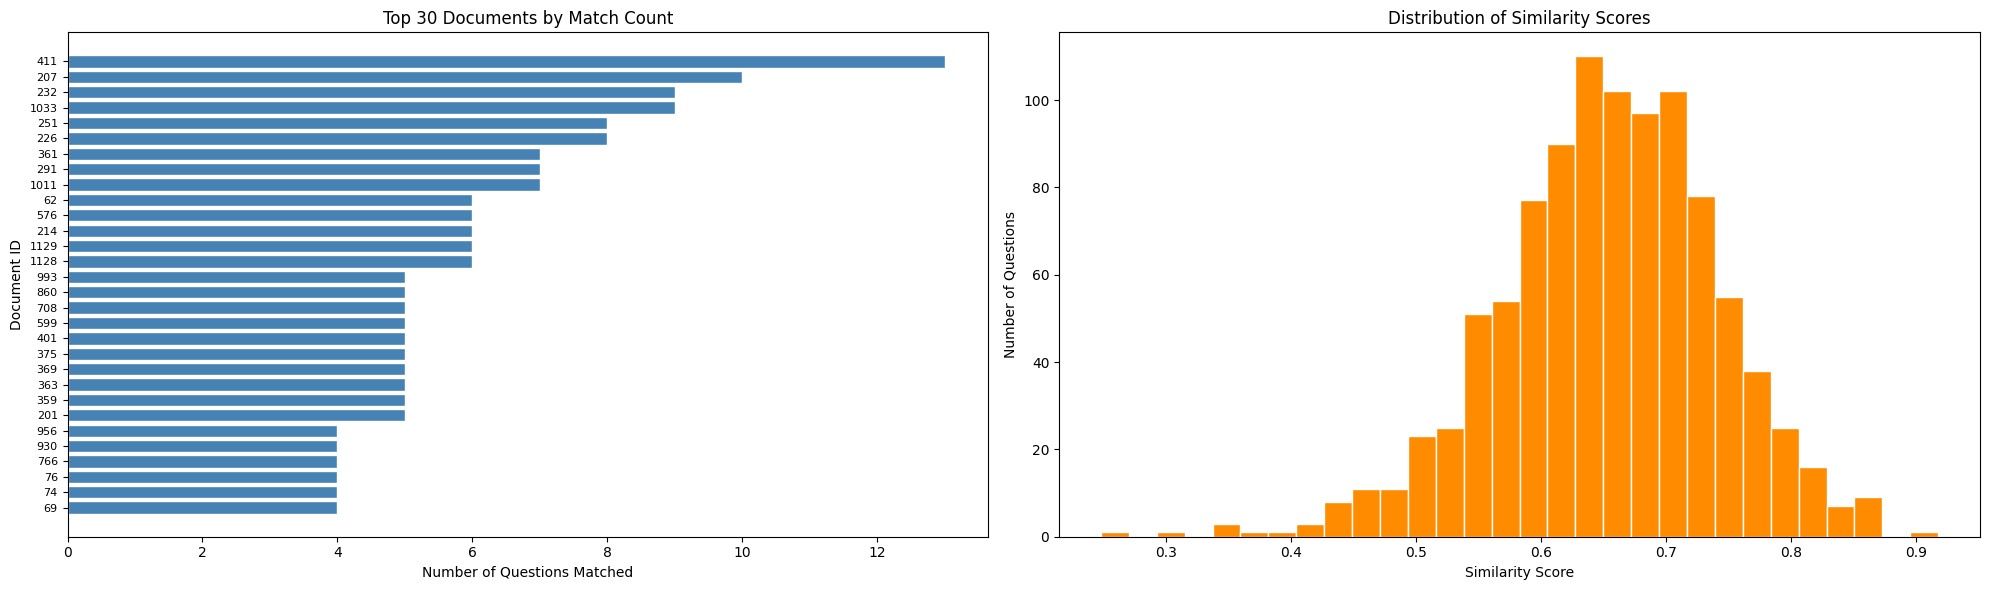

Saved plot to question_doc_distribution.png

── Summary ──────────────────────────────
Total questions:       1000
Unique docs matched:   497
Most matched doc:      ('411', 13)
Avg similarity score:  0.6530
Min similarity score:  0.2479
Max similarity score:  0.9176


In [53]:
# Attach each policy question embedding to the most relevant policy chunk.
# Prefer Experiment B.II's sentence-chunk store if it exists in memory; otherwise fall back to Section A.
attach_collection = collection_alt if 'collection_alt' in globals() else collection
attach_docs = docs_alt if 'docs_alt' in globals() else docs

matched = match_questions_to_documents(
    questions=policy_questions['Question'].to_list(),               # list of 1000 question strings
    question_embeddings=policy_questions_embeddings,
    collection=attach_collection,
    docs=attach_docs,
    n_results=1,                       # top-N docs per question
    save_path="question_doc_chunk_matches_b3.json"
)

In [54]:
print(matched[0])

{'question_id': 0, 'question': "What is Carnegie Mellon University's stated vision as described in the Student Handbook?", 'matched_document': '11 \n \n \nclassroom, they should strive to advance the art of teaching. One of the primary goals should \nbe to instill in their students a desire to learn and an enthusiasm for the subject matter at \nhand. The faculty as a whole also has the major responsibility for establishing and \nmaintaining curricula which meet the standards and fulfill the educational goals of the \nuniversity. Students \nCarnegie Mellon, as a private university, selects from among its applicants those students \nwho have demonstrated the qualifications for achieving professional competence in one of \nthe fields in which the university offers instruction. Any student who meets its standards is \nwelcome to apply for admission and, if admitted, to remain at the university so long as he or \nshe abides by its rules.', 'matched_doc_id': '19', 'similarity_score': 0.6301}

In [55]:
# Remake the vector store using the new embeddings created from the Policy Question Dataset.
# Document payload = matched policy chunks; embedding payload = policy-question embeddings.

if "matched" not in globals() or len(matched) != len(policy_questions):
    raise RuntimeError("Run the prior match_questions_to_documents cell first so `matched` is available.")

# Build B.III records.
docs_b3 = [item["matched_document"] for item in matched]
ids_b3 = [f"pq_{i:04d}" for i in range(len(docs_b3))]
metadatas_b3 = []
for i, row in policy_questions.reset_index(drop=True).iterrows():
    metadatas_b3.append({
        "question_id": int(i),
        "question_number": str(row.get("Question Number", i + 1)),
        "section": str(row.get("Section", "")),
        "question": str(row.get("Question", "")),
        "source_doc_id": str(matched[i].get("matched_doc_id", "")),
        "source_similarity": float(matched[i].get("similarity_score", 0.0)),
    })

dense_vectors_b3 = policy_questions_embeddings["dense"]
if isinstance(dense_vectors_b3, np.ndarray):
    dense_vectors_b3 = dense_vectors_b3.tolist()

# Build / refresh dedicated B.III collection.
client_b3, collection_b3 = create_client(vectorStoreName="hw02_alt_embeddings", metric="cosine")

existing_count_b3 = collection_b3.count()
if existing_count_b3 > 0:
    existing_ids_b3 = collection_b3.get(include=[]).get("ids", [])
    if existing_ids_b3:
        collection_b3.delete(ids=existing_ids_b3)

collection_b3.add(
    ids=ids_b3,
    documents=docs_b3,
    embeddings=dense_vectors_b3,
    metadatas=metadatas_b3,
)

print(f"Collection 'hw02_alt_embeddings' count: {collection_b3.count()}")
print(f"Loaded {len(docs_b3)} records (question embeddings + attached chunk metadata)")


Collection 'hw02_alt_embeddings' ready. Count: 1000
Collection 'hw02_alt_embeddings' count: 1000
Loaded 1000 records (question embeddings + attached chunk metadata)


In [56]:
# Define the query chosen for the experiment (same Section B query).
qb_b3 = "What is the academic integrity policy?"
qb_b3

'What is the academic integrity policy?'

In [57]:
# Encode the query for the experiment using the same embedding model.
question_embedding_qb_b3 = embedder.encode_documents([qb_b3])
question_embedding_qb_b3

[array([-3.73943225e-02,  9.98494998e-02, -3.68607417e-02, -3.51854265e-02,
         2.37348061e-02, -1.70656275e-02, -3.40798721e-02, -8.68340358e-02,
        -1.54793228e-03,  6.92967027e-02,  5.04572093e-02,  8.24571624e-02,
        -3.37054208e-02, -2.73006968e-02, -9.46990624e-02,  1.80964712e-02,
        -5.24988510e-02,  1.17457379e-02, -4.06726040e-02, -2.24045962e-02,
         5.08646062e-03,  2.71296259e-02,  4.15171981e-02,  4.43458706e-02,
        -3.75666879e-02, -4.56076302e-03, -3.13719781e-03, -5.42213283e-02,
        -5.58070950e-02, -8.69289935e-02, -5.29440790e-02, -2.69563571e-02,
         1.82095859e-02,  3.29573527e-02, -2.11109314e-02,  9.53177139e-02,
         2.09778566e-02, -3.37007409e-03,  2.45418977e-02,  2.53806403e-03,
        -2.58776639e-02, -2.88361683e-02, -3.16623226e-02,  3.73185277e-02,
        -1.05607314e-02, -7.15818703e-02,  4.87464555e-02, -6.59105629e-02,
         9.01939720e-03, -1.15874009e-02, -6.04182780e-02, -3.66622619e-02,
         2.4

In [58]:
# Search the vector store (varying retrieved_number / top_k) and retrieve information.
top_ks_b3 = [1, 3, 5, 10]
vs_search_results_b3 = {}

query_dense_b3 = question_embedding_qb_b3
if isinstance(query_dense_b3, np.ndarray):
    query_dense_b3 = query_dense_b3.tolist()

for k in top_ks_b3:
    vs_search_results_b3[k] = collection_b3.query(
        query_embeddings=query_dense_b3,
        n_results=k,
        include=["documents", "metadatas", "distances"],
    )
    print(f"Top {k} documents for Question {qb_b3}:")
    for rank, doc in enumerate(vs_search_results_b3[k]["documents"][0], start=1):
        md = vs_search_results_b3[k]["metadatas"][0][rank - 1]
        print(f"[{rank}] matched_question={md.get('question')}")
        print(doc + "\n")


Top 1 documents for Question What is the academic integrity policy?:
[1] matched_question=What does the policy say universities must do when conflicts concerning integrity arise?
In all cases involving alleged violations of the University Policy on 
Academic Integrity, the following procedures apply:

Top 3 documents for Question What is the academic integrity policy?:
[1] matched_question=What does the policy say universities must do when conflicts concerning integrity arise?
In all cases involving alleged violations of the University Policy on 
Academic Integrity, the following procedures apply:

[2] matched_question=What does the Academic Integrity Policy state about a student's responsibility for their own work?
You should also become familiar with the following sources, 
which are the primary documents governing academic policies: the University Policies website, 
the Undergraduate Catalog, and individual department handbooks provided to each graduate 
student. Academic Disciplina

In [59]:
# Save the input and output from the vector store.

# **Section C: Evaluation.**


## *Design an LLM Judge to Produce Custom Metrics*

**Tasks:**
> [1] Using a Pydantic Base Model technique, design an LLM Judge to automatically score the quality of the vector store responses with respect to the query submitted to the store AND a specific characteristics of the text; for example: factuality, relevance, specificity, helpfulness.

> [2] Measure the quality of the information retrieval using the LLM Judge.

In [60]:
import os
import json
from mlx_lm import load, generate

MODEL_PATH = os.environ.get("QWEN_MODEL_PATH", "mlx-community/Qwen3.5-9B-OptiQ-4bit")
model, tokenizer = load(MODEL_PATH)

with open("question_doc_chunk_matches.json") as f:
    matched = json.load(f)

print(f"Loaded {len(matched)} matched question-document pairs from question_doc_chunk_matches.json")
print(f"Model loaded: {MODEL_PATH}")
print(f"Sample: {matched[0]}")

Fetching 8 files: 100%|██████████| 8/8 [00:00<00:00, 109655.01it/s]


Loaded 1000 matched question-document pairs from question_doc_chunk_matches.json
Model loaded: mlx-community/Qwen3.5-9B-OptiQ-4bit
Sample: {'question_id': 0, 'question': "What is Carnegie Mellon University's stated vision as described in the Student Handbook?", 'matched_document': 'educates its students to become professionals who will serve society with integrity. The university also creates and disseminates new knowledge and expressions of knowledge in ways that benefit society. Carnegie Mellon strives to serve the changing needs of society through the three primary goals outlined in its mission statement: to', 'matched_doc_id': '56', 'similarity_score': 0.6736}


In [61]:
def evaluate_relevance_local(
    question:     str,
    question_id:  int,
    matched_docs: list,
    model,
    tokenizer,
    model_id:     str = MODEL_PATH,
    construct:    str = "relevance",
    max_tokens:   int = 1500,
) -> QuestionRelevanceEval:
    """Score document relevance using a local MLX model instead of HF Inference API."""

    docs_text = "\n\n".join([
        f"[Doc {d['matched_doc_id']}]: {d['matched_document']}"
        for d in matched_docs
    ])

    doc_template = ", ".join([
        f'{{"doc_id": "{d["matched_doc_id"]}", "document_snippet": "...", '
        f'"relevance_score": 0, "relevance_rationale": "..."}}'
        for d in matched_docs
    ])

    prompt = f"""You are evaluating the {construct} of retrieved documents to a question.

Question: {question}

Retrieved Documents:
{docs_text}

Score each document's {construct} on a 5-point Likert scale:
1 = Strongly Disagree (not {construct} at all)
2 = Disagree (mostly not {construct})
3 = Neutral (neither somewhat {construct} nor somewhat not {construct})
4 = Agree (mostly {construct})
5 = Strongly Agree (highly {construct})

Respond with ONLY a valid JSON object, no markdown, no extra text:
{{
  "question_id": {question_id},
  "question": {json.dumps(question)},
  "construct": "{construct}",
  "document_evals": [{doc_template}],
  "overall_score": 0,
  "overall_rationale": "<summary>"
}}

"overall_score" must be a single integer from 1 to 5. Do not average — pick the most representative score."""

    messages = [
        {"role": "system", "content": "You are a JSON-only evaluator. Output valid JSON with no extra text."},
        {"role": "user", "content": prompt},
    ]
    formatted = tokenizer.apply_chat_template(
        messages, add_generation_prompt=True, tokenize=False,
        enable_thinking=False,
    )

    input_ids = tokenizer.encode(formatted)
    input_tokens = len(input_ids)

    raw = generate(
        model, tokenizer, prompt=formatted,
        max_tokens=max_tokens, verbose=False,
    )

    output_tokens = len(tokenizer.encode(raw))

    raw = re.sub(r"<think>.*?</think>", "", raw, flags=re.DOTALL).strip()
    raw = re.sub(r"```(?:json)?\s*", "", raw).strip()
    json_match = re.search(r'\{.*\}', raw, re.DOTALL)
    if not json_match:
        raise ValueError(f"No JSON found in response:\n{raw}")

    parsed = json.loads(json_match.group())

    if "overall_score" in parsed:
        parsed["overall_score"] = min(5, max(1, round(parsed["overall_score"])))

    token_usage = TokenUsage(**get_token_cost(
        model_id=model_id,
        input_tokens=input_tokens,
        output_tokens=output_tokens,
    ))

    return QuestionRelevanceEval(**parsed, token_usage=token_usage)

print("evaluate_relevance_local() defined — uses local MLX model")

evaluate_relevance_local() defined — uses local MLX model


In [62]:
eval_result = evaluate_relevance_local(
    question=matched[0]["question"],
    question_id=matched[0]["question_id"],
    matched_docs=matched[:3],
    model=model,
    tokenizer=tokenizer,
)

print(f"Overall: {eval_result.overall_score.name} ({eval_result.overall_score})")
print(f"Mean:    {eval_result.mean_score:.2f}")
print(f"Distribution: {eval_result.score_distribution}")

Overall: DISAGREE (2)
Mean:    1.67
Distribution: {'STRONGLY_DISAGREE': 1, 'DISAGREE': 2, 'NEUTRAL': 0, 'AGREE': 0, 'STRONGLY_AGREE': 0}


In [63]:
import time

# Approximate cloud-equivalent pricing for the local Qwen ~9B model (per 1M tokens)
MODEL_PRICING[MODEL_PATH] = (0.10, 0.10)

def evaluate_vector_store(
    store_name, collection, query, embedder,
    model, tokenizer, model_id=MODEL_PATH,
    top_k=3, construct="relevance",
):
    """Run a timed search + LLM Judge scoring for one query against a vector store."""

    query_emb = embedder.encode_documents([query])
    if isinstance(query_emb, np.ndarray):
        query_emb = query_emb.tolist()

    t0 = time.time()
    results = collection.query(
        query_embeddings=query_emb,
        n_results=top_k,
        include=["documents", "metadatas", "distances"],
    )
    search_time = time.time() - t0

    mdocs = [
        {
            "matched_doc_id": results["ids"][0][j],
            "matched_document": results["documents"][0][j],
            "similarity_score": round(1 - results["distances"][0][j], 4),
        }
        for j in range(len(results["documents"][0]))
    ]

    eval_result = evaluate_relevance_local(
        question=query, question_id=0,
        matched_docs=mdocs, model=model,
        tokenizer=tokenizer, model_id=model_id,
        construct=construct,
    )

    cost = eval_result.token_usage.cost_usd if eval_result.token_usage else None
    avg_distance = round(sum(results["distances"][0]) / len(results["distances"][0]), 4)

    return {
        "store_name": store_name,
        "eval_result": eval_result,
        "search_time": search_time,
        "cost": cost,
        "top_k": top_k,
        "avg_distance": avg_distance,
    }

print(f"evaluate_vector_store() defined — pricing: ${MODEL_PRICING[MODEL_PATH][0]}/1M in, ${MODEL_PRICING[MODEL_PATH][1]}/1M out")

evaluate_vector_store() defined — pricing: $0.1/1M in, $0.1/1M out


## *Metric Selection: Precision and Recall*

**Tasks:**
> [1] Select evaluation metrics to assess the quality of the information retrieved from the vector store.

> [2] Measure the quality of the information retrieval using the evaluation metrics that you chose.


Evaluating: A: Word-Chunked
  Search time:    0.0223s
  Avg distance:   0.1913
  Overall:        AGREE (4)
  Mean score:     4.00
  Distribution:   {'STRONGLY_DISAGREE': 0, 'DISAGREE': 0, 'NEUTRAL': 1, 'AGREE': 1, 'STRONGLY_AGREE': 1}
  Cost:           $0.00009680

Evaluating: B.II: Sentence-Chunked
  Search time:    0.0032s
  Avg distance:   0.2163
  Overall:        AGREE (4)
  Mean score:     3.00
  Distribution:   {'STRONGLY_DISAGREE': 0, 'DISAGREE': 1, 'NEUTRAL': 1, 'AGREE': 1, 'STRONGLY_AGREE': 0}
  Cost:           $0.00010790

Evaluating: B.III: Policy-Question Emb.
  Search time:    0.0038s
  Avg distance:   0.2099
  Overall:        AGREE (4)
  Mean score:     2.67
  Distribution:   {'STRONGLY_DISAGREE': 0, 'DISAGREE': 2, 'NEUTRAL': 0, 'AGREE': 1, 'STRONGLY_AGREE': 0}
  Cost:           $0.00011190

LLM JUDGE PRECISION & RECALL PER VECTOR STORE

--- A: Word-Chunked ---


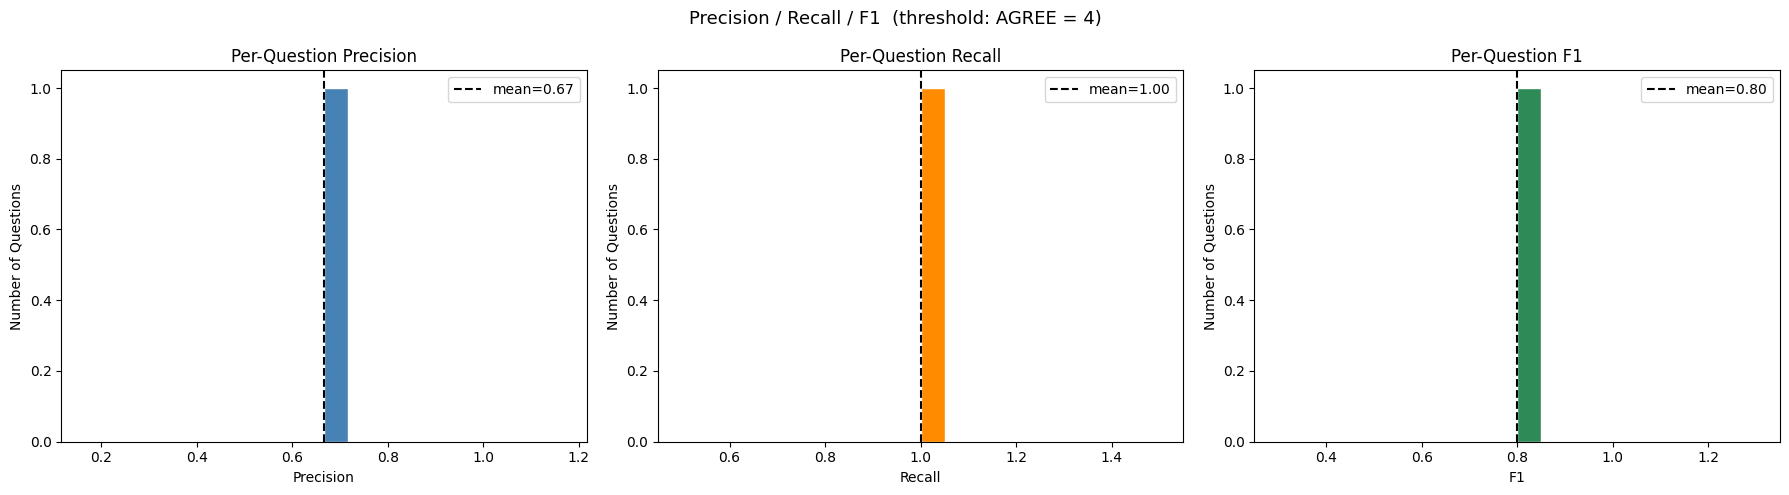


── Summary (threshold ≥ AGREE) ─────────────────
Macro  Precision: 0.6667  Recall: 1.0000  F1: 0.8000
Micro  Precision: 0.6667  Recall: 1.0000  F1: 0.8000

--- B.II: Sentence-Chunked ---


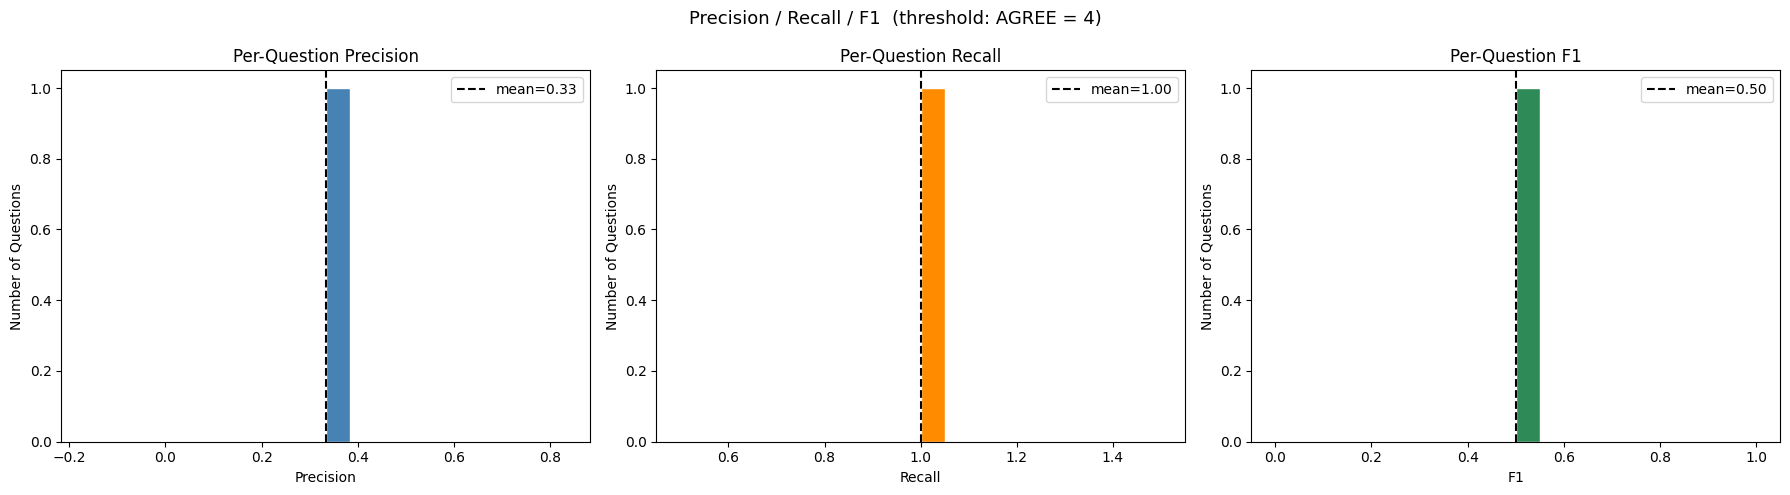


── Summary (threshold ≥ AGREE) ─────────────────
Macro  Precision: 0.3333  Recall: 1.0000  F1: 0.5000
Micro  Precision: 0.3333  Recall: 1.0000  F1: 0.5000

--- B.III: Policy-Question Emb. ---


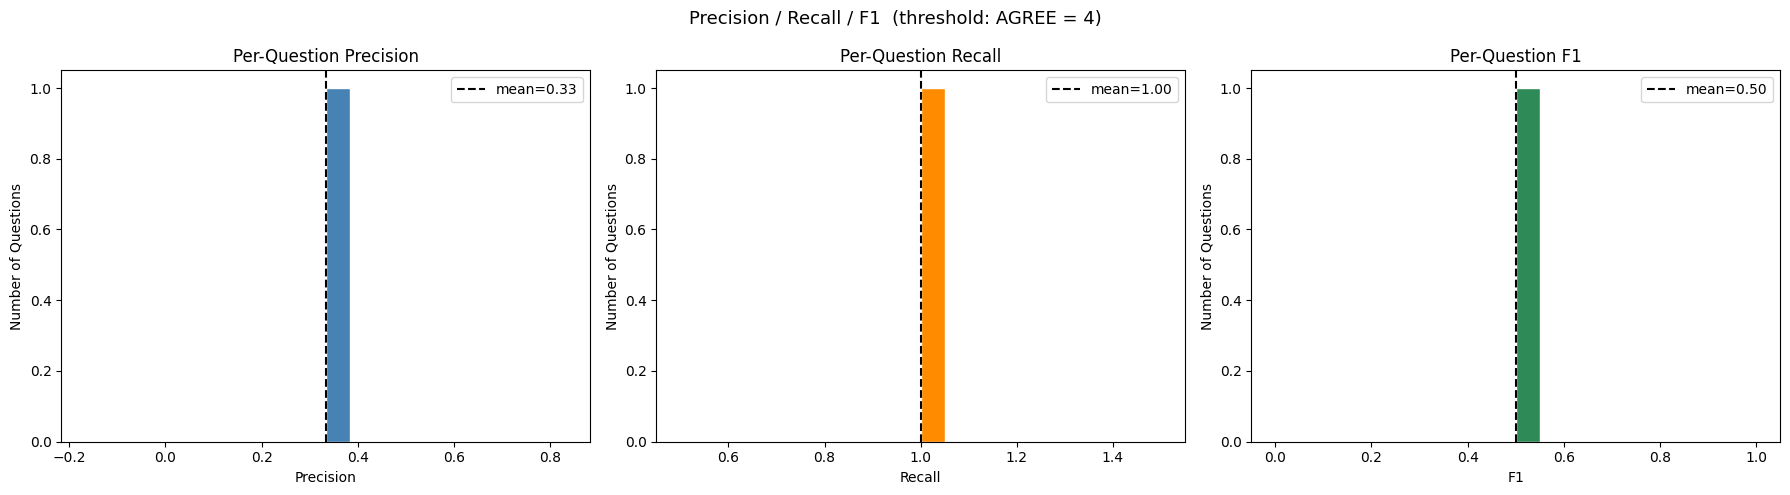


── Summary (threshold ≥ AGREE) ─────────────────
Macro  Precision: 0.3333  Recall: 1.0000  F1: 0.5000
Micro  Precision: 0.3333  Recall: 1.0000  F1: 0.5000

EVALUATION SUMMARY — Query: "What is the academic integrity policy?"
Model: mlx-community/Qwen3.5-9B-OptiQ-4bit
Pricing: $0.1/1M input, $0.1/1M output
               Vector Store  Search Time (s)  Avg Distance  LLM Judge Score  Mean Doc Score  Precision  Recall  F1  Cost ($)
            A: Word-Chunked           0.0223        0.1913                4            4.00     0.6667     1.0 0.8  0.000097
     B.II: Sentence-Chunked           0.0032        0.2163                4            3.00     0.3333     1.0 0.5  0.000108
B.III: Policy-Question Emb.           0.0038        0.2099                4            2.67     0.3333     1.0 0.5  0.000112

PER-STORE COST DETAIL
  A: Word-Chunked                      in=  486  out=  482  cost=$0.00009680
  B.II: Sentence-Chunked               in=  694  out=  385  cost=$0.00010790
  B.III: Policy

In [ ]:
eval_query = qb  # Section B query: "What is the academic integrity policy?"
eval_top_k = 3

stores = {
    "A":  ("A: Word-Chunked",              collection),
    "B2": ("B.II: Sentence-Chunked",       collection_alt),
    "B3": ("B.III: Policy-Question Emb.",   collection_b3),
}

store_evals = {}

for key, (name, coll) in stores.items():
    print(f"\n{'='*60}")
    print(f"Evaluating: {name}")
    print(f"{'='*60}")
    store_evals[key] = evaluate_vector_store(
        store_name=name,
        collection=coll,
        query=eval_query,
        embedder=embedder,
        model=model,
        tokenizer=tokenizer,
        top_k=eval_top_k,
    )
    er = store_evals[key]["eval_result"]
    st = store_evals[key]["search_time"]
    cost = store_evals[key]["cost"]
    ad = store_evals[key]["avg_distance"]
    print(f"  Search time:    {st:.4f}s")
    print(f"  Avg distance:   {ad}")
    print(f"  Overall:        {er.overall_score.name} ({er.overall_score})")
    print(f"  Mean score:     {er.mean_score:.2f}")
    print(f"  Distribution:   {er.score_distribution}")
    print(f"  Cost:           ${cost:.8f}" if cost else "  Cost:           N/A")

# Precision & Recall per store
print(f"\n{'='*60}")
print("LLM JUDGE PRECISION & RECALL PER VECTOR STORE")
print(f"{'='*60}")

pr_summaries = {}
for key in ["A", "B2", "B3"]:
    se = store_evals[key]
    er = se["eval_result"]
    print(f"\n--- {se['store_name']} ---")
    pr_summaries[key] = evaluate_precision_recall(
        matched=matched,
        eval_results=[er],
        relevance_threshold=LikertScore.AGREE,
    )

# Comparison table
rows = []
for key in ["A", "B2", "B3"]:
    se = store_evals[key]
    pr = pr_summaries[key]
    rows.append({
        "Vector Store":         se["store_name"],
        "Search Time (s)":      round(se["search_time"], 4),
        "Avg Distance":         se["avg_distance"],
        "LLM Judge Score":      int(se["eval_result"].overall_score),
        "Mean Doc Score":       round(se["eval_result"].mean_score, 2),
        "Precision":            pr["macro_precision"],
        "Recall":               pr["macro_recall"],
        "F1":                   pr["macro_f1"],
        "Cost ($)":             round(se["cost"], 8) if se["cost"] else "N/A",
    })

comparison_df = pd.DataFrame(rows)
print(f"\n{'='*80}")
print(f"EVALUATION SUMMARY — Query: \"{eval_query}\"")
print(f"Model: {MODEL_PATH}")
print(f"Pricing: ${MODEL_PRICING[MODEL_PATH][0]}/1M input, ${MODEL_PRICING[MODEL_PATH][1]}/1M output")
print(f"{'='*80}")
print(comparison_df.to_string(index=False))

print(f"\n{'='*80}")
print("PER-STORE COST DETAIL")
print(f"{'='*80}")
for key in ["A", "B2", "B3"]:
    se = store_evals[key]
    er = se["eval_result"]
    tu = er.token_usage
    if tu:
        cost_str = f"${tu.cost_usd:.8f}" if tu.cost_usd else "N/A"
        print(f"  {se['store_name']:35s}  in={tu.input_tokens:5d}  out={tu.output_tokens:5d}  cost={cost_str}")

avg_cost = sum(se["cost"] for se in store_evals.values() if se["cost"]) / len(store_evals)
print(f"\n  Average cost across 3 stores: ${avg_cost:.8f}")

# **Section D: Write a report providing your experimental results (from Sections: A, B and C), detailing your experimental design, methodology, and assessments of the quality of the information retrieval from the two distinct Vector Stores.**

In [65]:
# Homework Questions List: https://docs.google.com/document/d/1-TF9NjdrTxvkTDzK4BS2tSGuodKEvNClaEsWoPsfKMc/edit?usp=sharing